In [46]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg 

#### 1. Import Directory and Path Names

In [47]:
files ={
    "file1" : "/Users/azd/Desktop/CV - Assignment 2/image pairs/image pairs_01_01.jpg",
    "file2" : "/Users/azd/Desktop/CV - Assignment 2/image pairs/image pairs_01_02.jpg",
    "file3" : "/Users/azd/Desktop/CV - Assignment 2/image pairs/image pairs_02_01.png",
    "file4" : "/Users/azd/Desktop/CV - Assignment 2/image pairs/image pairs_02_02.png",
    "file5" : "/Users/azd/Desktop/CV - Assignment 2/image pairs/image pairs_03_01.jpg",
    "file6" : "/Users/azd/Desktop/CV - Assignment 2/image pairs/image pairs_03_02.jpg",
    "file7" : "/Users/azd/Desktop/CV - Assignment 2/image pairs/image pairs_04_01.jpg",
    "file8" : "/Users/azd/Desktop/CV - Assignment 2/image pairs/image pairs_04_02.jpg",
}


#### 2. Display Sample Images

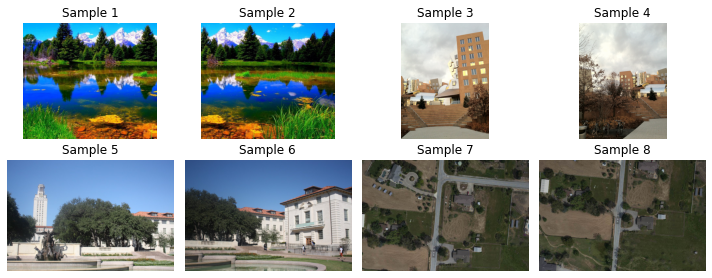

In [48]:
fig, axs = plt.subplots(2, 4,figsize=(10, 4))

for i in range(1, 5): 
    key = f"file{i}"
    img = plt.imread(f"{files[key]}")
    axs[0, i-1].set_title(f'Sample {i}')
    axs[0, i-1].imshow(img)
    for ax in axs.flatten():
        ax.axis('off')

for i in range(5, 9): 
    key = f"file{i}"
    img = plt.imread(f"{files[key]}")
    axs[1, i-5].set_title(f'Sample {i}')
    axs[1, i-5].imshow(img)
    for ax in axs.flatten():
        ax.axis('off')
plt.tight_layout()      
plt.show()

#### 3. Harris Corner Detection

In [77]:
def harris(img_dir):
    img = cv2.imread(img_dir)
    gray = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)  # Turn image to gray

    harris = cv2.cornerHarris(gray,2,3,0.04)  # blockSize=2, ksize=3, k=0.04
    
    # Normalize for visualization
    harris_norm = np.empty(harris.shape, dtype=np.float32)
    cv2.normalize(harris, harris_norm, alpha=0, beta=255, norm_type=cv2.NORM_MINMAX)
    harris_norm_scaled = cv2.convertScaleAbs(harris_norm)

    # Get coordinates of detected corners
    corner_coords = np.argwhere(harris_norm > 0.01 * harris_norm.max())
    
    # Result is dilated for marking the corners, not important
    harris = cv2.dilate(harris,None)

    # Threshold for an optimal value, it may vary depending on the image.
    img[harris>0.01*harris.max()]=[0,0,255]
    
    img_color = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    #plt.figure("Harris detector")
    #plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)), plt.title("Harris")
    #plt.xticks([]), plt.yticks([])
    #plt.show()
    
    return img_color, corner_coords # 2 outputs



    
def sift_descriptor(img, corners):
    keypoints = [cv2.KeyPoint(x, y,1) for x, y in corners]
    sift = cv2.SIFT_create()
    _, descriptors = sift.compute(img, keypoints)
    return descriptors



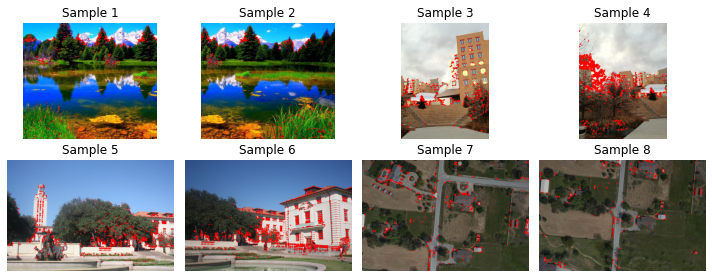

Coordinates for detected corners in Sample 1
[[  0   0]
 [  0   1]
 [  0   2]
 ...
 [709 815]
 [709 816]
 [709 817]]


Coordinates for detected corners in Sample 2
[[  0   0]
 [  0   1]
 [  0   2]
 ...
 [708 813]
 [708 814]
 [708 815]]


Coordinates for detected corners in Sample 3
[[  0   0]
 [  0   1]
 [  0   2]
 ...
 [499 372]
 [499 373]
 [499 374]]


Coordinates for detected corners in Sample 4
[[  0   0]
 [  0   1]
 [  0   2]
 ...
 [499 372]
 [499 373]
 [499 374]]


Coordinates for detected corners in Sample 5
[[   0    0]
 [   0    1]
 [   0    2]
 ...
 [ 682 1021]
 [ 682 1022]
 [ 682 1023]]


Coordinates for detected corners in Sample 6
[[   0    0]
 [   0    1]
 [   0    2]
 ...
 [ 682 1021]
 [ 682 1022]
 [ 682 1023]]


Coordinates for detected corners in Sample 7
[[  0   0]
 [  0   1]
 [  0   2]
 ...
 [426 637]
 [426 638]
 [426 639]]


Coordinates for detected corners in Sample 8
[[  0   0]
 [  0   1]
 [  0   2]
 ...
 [426 637]
 [426 638]
 [426 639]]




In [79]:
fig, axs = plt.subplots(2, 4,figsize=(10, 4))

# For visualisation

for i in range(1, 5): 
    key = f"file{i}"
    img = f"{files[key]}" 
    outputs = harris(img)
    axs[0, i-1].set_title(f'Sample {i}')
    axs[0, i-1].imshow(outputs[0])
    for ax in axs.flatten():
        ax.axis('off')
    
for i in range(5, 9): 
    key = f"file{i}"
    img = f"{files[key]}"
    outputs = harris(img)
    axs[1, i-5].set_title(f'Sample {i}')
    axs[1, i-5].imshow(outputs[0])
    for ax in axs.flatten():
        ax.axis('off')
plt.tight_layout()      
plt.show()


# Compute corners and SIFT descriptors

for i in range(1, 9): 
    key = f"file{i}"
    img = f"{files[key]}"
    outputs = harris(img)
    #descriptors = sift_descriptor(img, outputs[1])
    print(f"Coordinates for detected corners in Sample {i}")
    print(outputs[1])
    print("\n")
    
    #print(f"SIFT Descriptors for Sample {i}")
    #print(descriptors)
    #print("\n")